# EDA Agrupación por Industria


En este notebook se realizara un analisis exploratorio despues de las agrupaciones y de la limpeza de los datos a ver como se organizan los nuevos generos. En esta agrupación titulada **Industria** en esta si tiene otro enfoque en el cual se agrupan en que tipo de industria separan los generos


|    | Grupo Resultante  | Géneros Incluidos                          | Justificación                                                                             
|-------|-------------------|--------------------------------------------|-------------------------------------------------------------------------------------------
|1| pop_rock          | Pop, Dance, Indie, Alternative, Rock       | El núcleo de la música popular contemporánea de bandas y solistas.                        |   |   |
|2| urban             | Hip-Hop, Rap, Reggaeton, Reggae, Ska       | Géneros de movimiento urbano y herencia rítmica latina/caribeña.                          |   |   |
|3| roots_and_soul    | Folk, Country, World, Blues, Soul, R&B     | Música con fuertes raíces culturales, tradicionales o de enfoque vocal orgánico.          |   |   |
|4| fine_arts         | Classical, Opera, Jazz                     | Música académica o de alta complejidad técnica interpretativa.                            |   |   |
|5| media_and_screen  | Soundtrack, Movie, Anime, Video Game Music | Música compuesta específicamente para acompañar contenido visual.                         |   |   |
|6| specialty_content | Children's Music, Comedy                   | Contenido que tiene un propósito específico no necesariamente musical (humor o infantil). |   |   |
|7| unclassified      | Cualquier otro género                      | Categoría de seguridad para datos nuevos o ruidosos.                                      |

In [1]:
import sys
import os
import importlib
import warnings
warnings.filterwarnings("ignore")

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import src.features.preprocessing_6 as prep
importlib.reload(prep) 

df, x, y = prep.preprocessing()

df.head(5)

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,es_muy_larga,genre_grouped
0,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814,False,media_and_screen
1,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816,False,media_and_screen
2,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368,False,media_and_screen
3,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227,False,media_and_screen
4,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390,False,media_and_screen


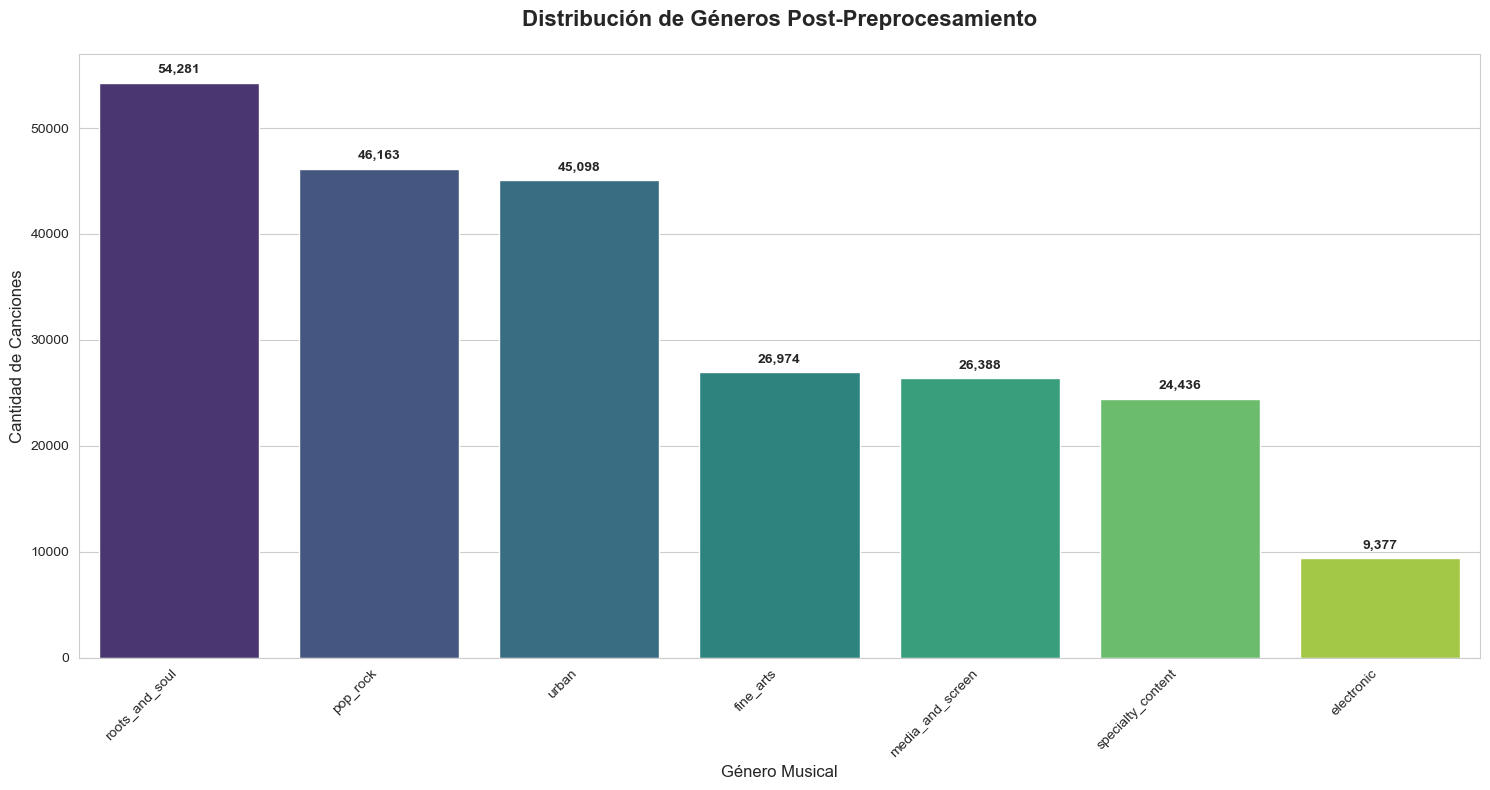

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

genre_counts = df['genre_grouped'].value_counts()

plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

ax = sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=10, fontweight='bold')
    
plt.title('Distribución de Géneros Post-Preprocesamiento', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Género Musical', fontsize=12)
plt.ylabel('Cantidad de Canciones', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [3]:
stats_despues = {
    'Num. Clases': df['genre_grouped'].nunique(),
    'Mínimo muestras': df['genre_grouped'].value_counts().min(),
    'Máximo muestras': df['genre_grouped'].value_counts().max(),
    'Promedio por clase': df['genre_grouped'].value_counts().mean()
}

stats_despues

{'Num. Clases': 7,
 'Mínimo muestras': 9377,
 'Máximo muestras': 54281,
 'Promedio por clase': np.float64(33245.28571428572)}

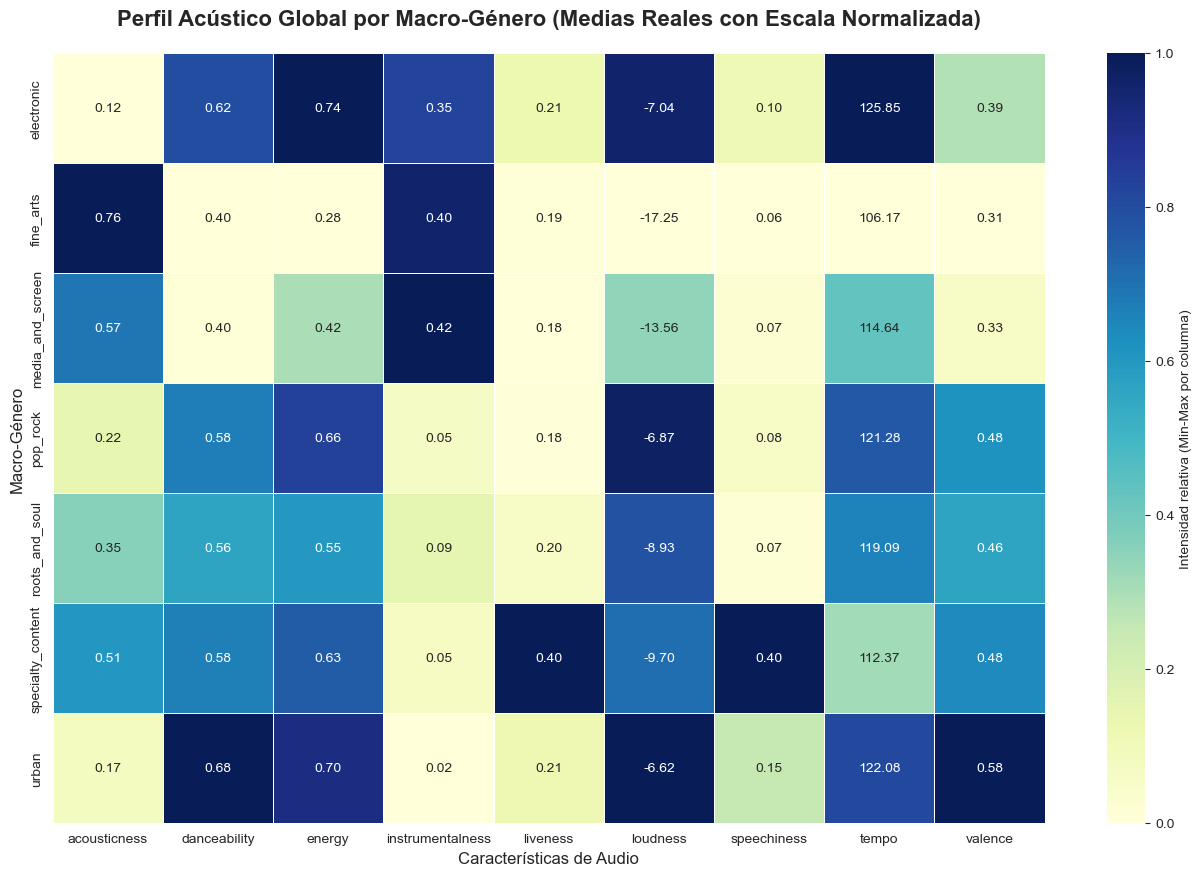

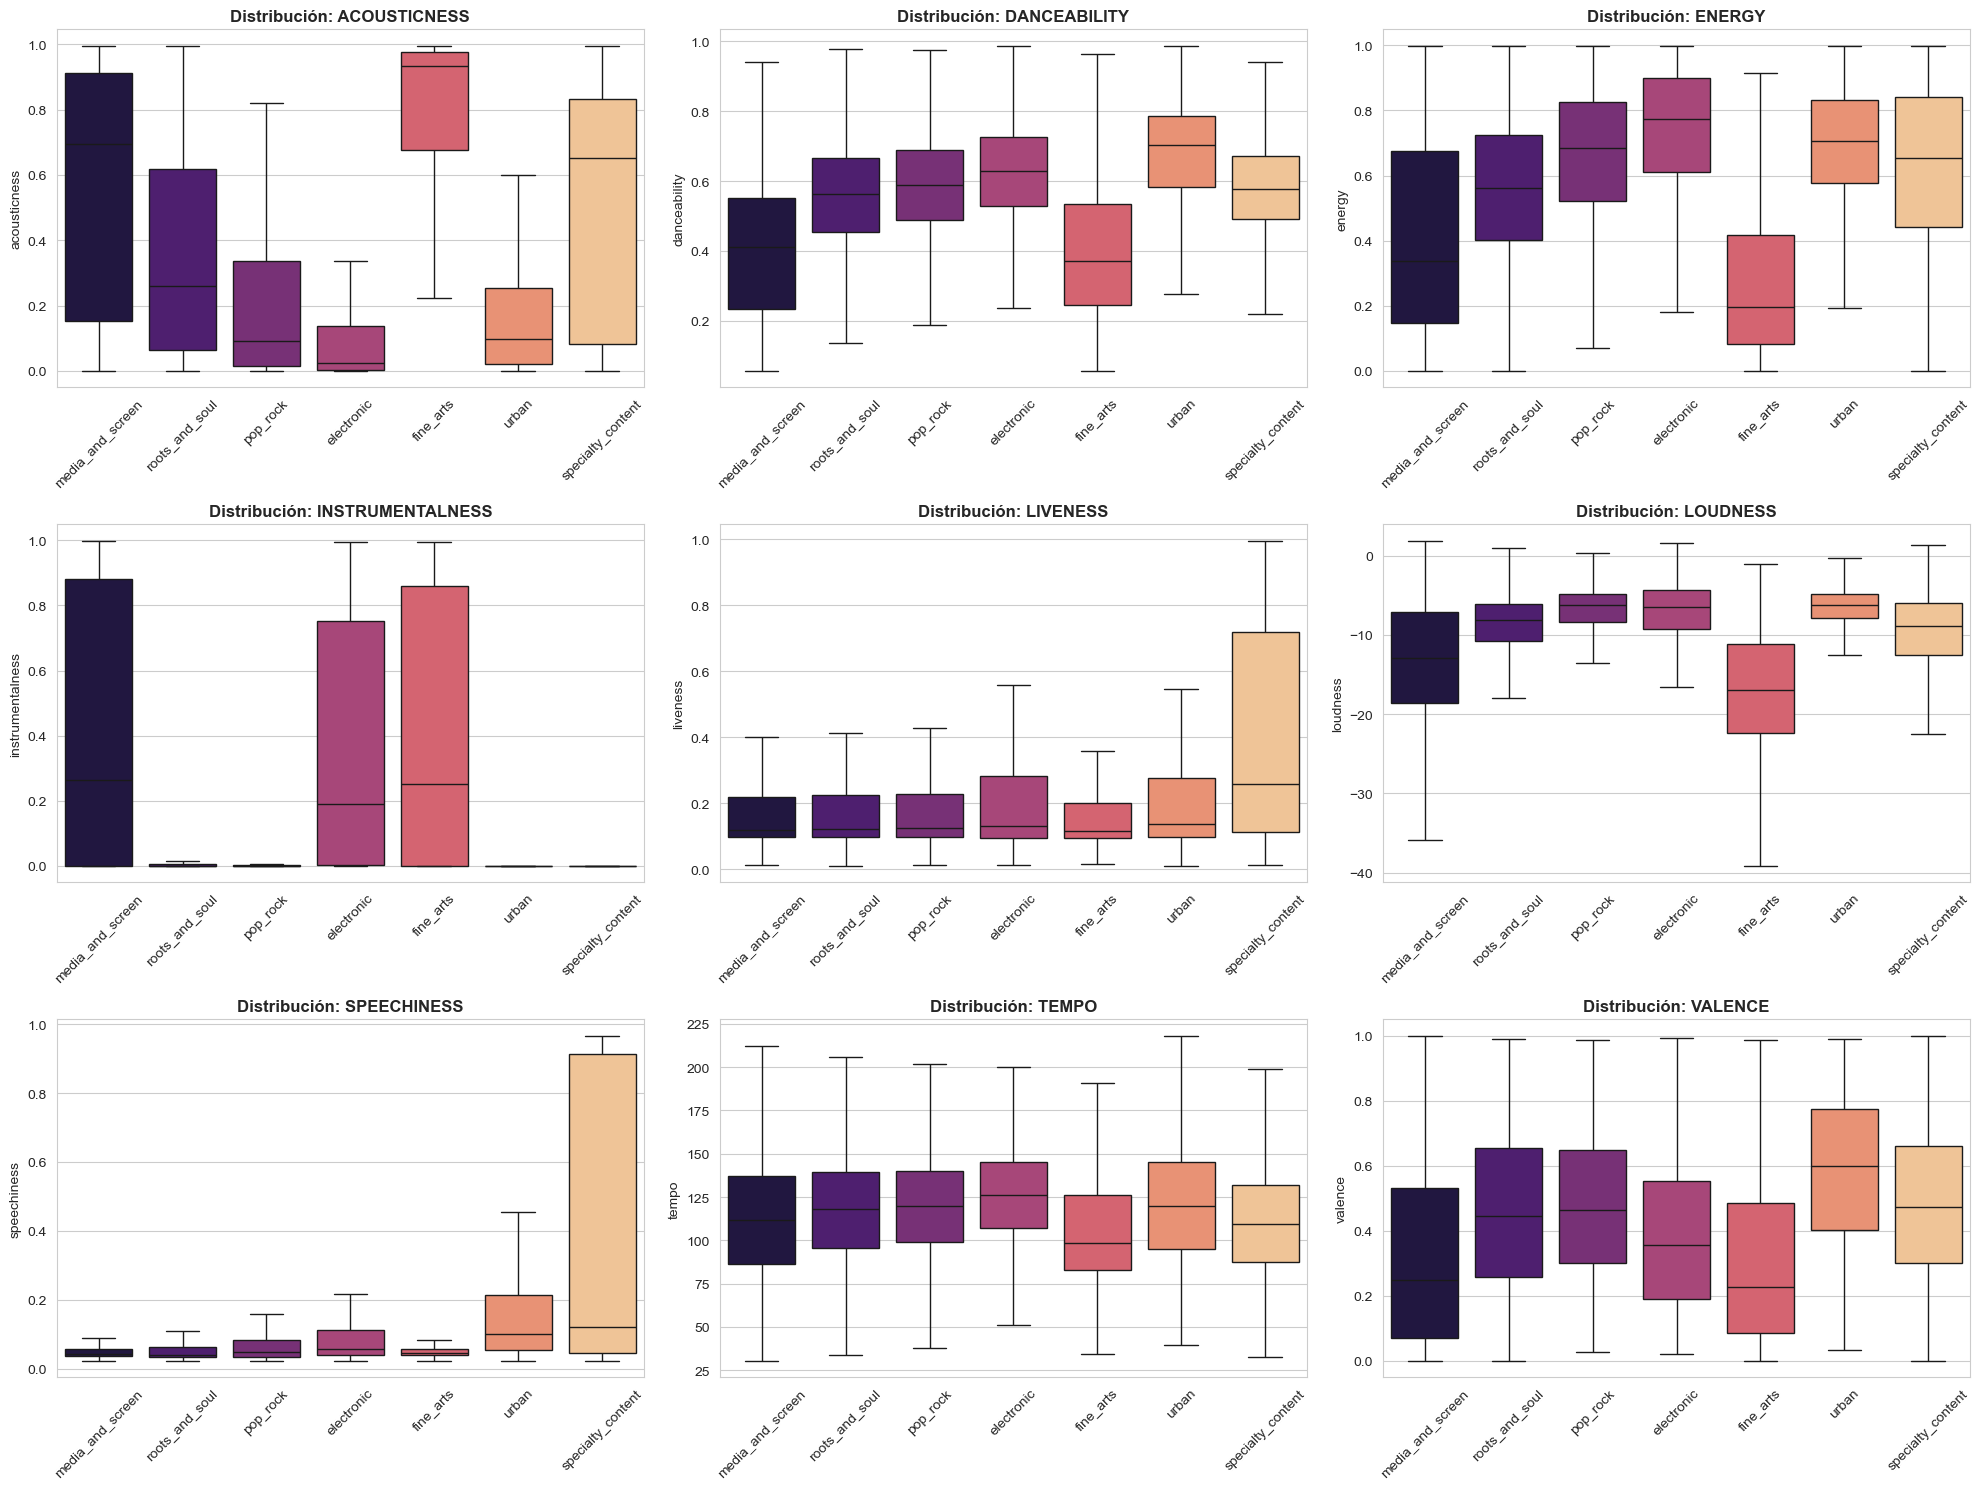

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# Matriz de correlación para las variables numéricas
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
for col in ['duration_ms', 'key', 'mode', 'time_signature', 'popularity']:
    if col in cols_numericas: cols_numericas.remove(col)
perfil_medios = df.groupby('genre_grouped')[cols_numericas].mean()
perfil_norm = (perfil_medios - perfil_medios.min()) / (perfil_medios.max() - perfil_medios.min())

plt.figure(figsize=(16, 10))
sns.heatmap(perfil_norm, 
            annot=perfil_medios,
            fmt=".2f", 
            cmap='YlGnBu', 
            linewidths=.5,
            cbar_kws={'label': 'Intensidad relativa (Min-Max por columna)'})

plt.title('Perfil Acústico Global por Macro-Género (Medias Reales con Escala Normalizada)', 
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Macro-Género', fontsize=12)
plt.xlabel('Características de Audio', fontsize=12)
plt.show()

# Boxplots com respecto a 'genre_grouped' para cada variable numérica

n_cols = 3
n_rows = (len(cols_numericas) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    sns.boxplot(x='genre_grouped', y=col, data=df, ax=axes[i], palette='magma', showfliers=False)
    axes[i].set_title(f'Distribución: {col.upper()}', fontsize=12, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

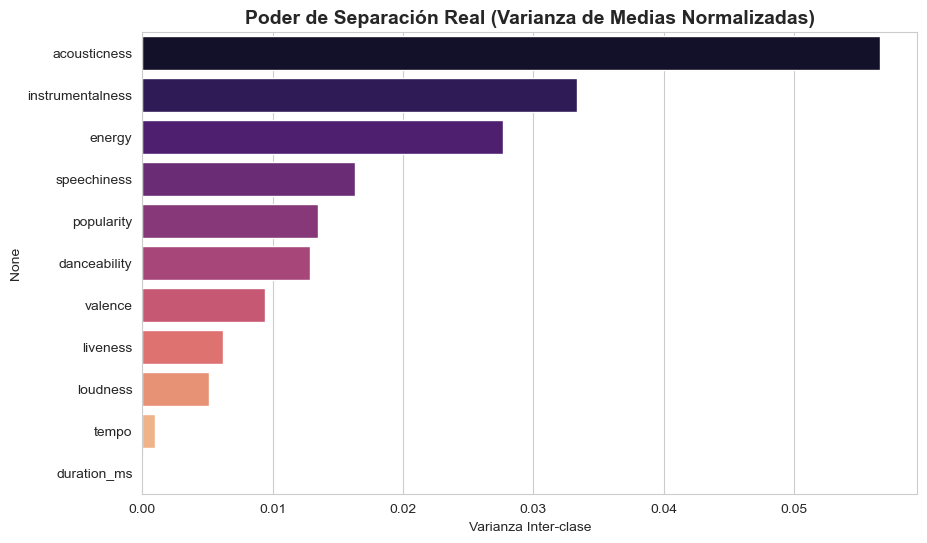

acousticness        0.056635
instrumentalness    0.033330
energy              0.027686
speechiness         0.016285
popularity          0.013465
danceability        0.012907
valence             0.009432
liveness            0.006183
loudness            0.005091
tempo               0.000997
duration_ms         0.000024
dtype: float64


In [6]:
from sklearn.preprocessing import MinMaxScaler

# 1. Seleccionamos solo las cuantitativas
cols_cuantitativas = df.select_dtypes(include=[np.number]).columns.tolist()

# 2. Normalizamos temporalmente para que todas valgan lo mismo (escala 0-1)
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[cols_cuantitativas]), columns=cols_cuantitativas)
df_scaled['genre_grouped'] = df['genre_grouped'].values

# 3. Calculamos la Varianza de las Medias
# Esto mide qué tanto se alejan los promedios de los grupos entre sí
ranking_separacion = df_scaled.groupby('genre_grouped').mean().var().sort_values(ascending=False)

# 4. Visualización
plt.figure(figsize=(10, 6))
sns.barplot(x=ranking_separacion.values, y=ranking_separacion.index, palette='magma')
plt.title('Poder de Separación Real (Varianza de Medias Normalizadas)', fontsize=14, fontweight='bold')
plt.xlabel('Varianza Inter-clase')
plt.show()

print(ranking_separacion)